In [51]:
%load_ext autoreload
%autoreload 2
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from data_handling import Data

import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[]
Series([], Name: begin_date, dtype: datetime64[ns])


/tmp/ipykernel_1312862/3003449493.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


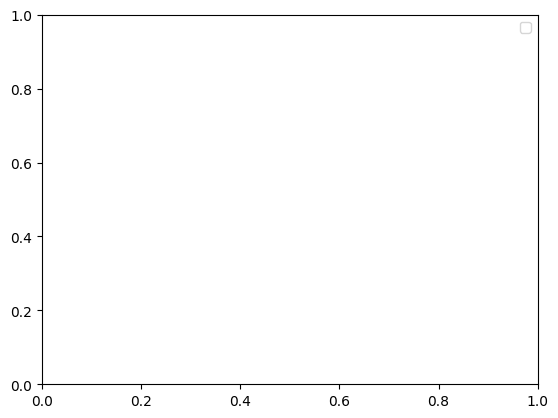

In [ ]:
site = 'NWB1'
glacier = 'taku'
model_fn = f'../../Output/{glacier}{site}_2026_02_10_1.nc'

# initialize data class
data = Data(glacier,site)

# open model dataset of interest and get seasonal mass balance
ds = xr.open_dataset(model_fn)
data.get_seasonal_mb(ds)

fig, ax = plt.subplots()
for start, end, mod, meas in zip(data.period_starts, data.period_ends, data.mod, data.meas):
    ax.plot([start, end], [mod, mod], label='Modeled', color=colors[0])
    ax.plot([start, end], [meas, meas], label='Measured', color='k', linestyle='--')

ax.legend()
plt.show()

In [ ]:
glaciersite = 'gulkanaB'
